# Analysis of the results from MGSD tests

MGSD dataset separated in 2 in-context learning strategies studied for role playing (click links to jump to section):

- [Zero-shot results analysis](#Zero-shot)

- [Few-shot results analysis](#Few-shot)

- [Chain-of-Thoughts results analysis](#Chain-of-Thoughts)

In [73]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [74]:
from datasets import load_dataset
import pandas as pd
from data_loader import load_mgsd_dataset, load_mentalmanip_dataset

## Loading the MGSD dataset.

dataset = load_dataset("wu981526092/MGSD")

data = dataset['train']
df = data.to_pandas()


sample_sizes_mgsd = {
    'stereotype': 250,
    'unrelated': 250,
}

sample_size_examples_mgsd = {
    'stereotype': 5,
    'unrelated': 5
}

sample_mgsd, sample_examples_mgsd = load_mgsd_dataset(
    df, 
    sample_sizes_mgsd, 
    sample_size_examples_mgsd,
    random_state=42,
    random_state_examples=0,
    )

# Zero-shot
### Analysis results zero-shot - stereotype detection

In [75]:
from typing import Literal
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.stereotypes_case import stereotypes_case
from profiles.profile_sets import PERSON_ETHNICS

ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"

merged_df = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/zero_shot/classic/results_stereotype_zero_shot_prompt_short_binary.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/zero_shot/role_playing_ethnics/*/results_stereotype_zero_shot_prompt_short_binary.csv",
    sample_df=sample_mgsd,
    case=stereotypes_case
)

=== Found 60 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'stereotype_type', 'profile1', 'profile2', 'profile3', 'profile4', 'profile5', 'profile6', 'profile7', 'profile8', 'profile9', 'profile10', 'profile11', 'profile12', 'profile13', 'profile14', 'profile15', 'profile16', 'profile17', 'profile18', 'profile19', 'profile20', 'profile21', 'profile22', 'profile23', 'profile24', 'profile25', 'profile26', 'profile27', 'profile28', 'profile29', 'profile30', 'profile31', 'profile32', 'profile33', 'profile34', 'profile35', 'profile36', 'profile37', 'profile38', 'profile39', 'profile40', 'profile41', 'profile42', 'profile43', 'profile44', 'profile45', 'profile46', 'profile47', 'profile48', 'profile49', 'profile50', 'profile51', 'profile52', 'profile53', 'profile54', 'profile55', 'profile56', 'profile57', 'profile58', 'profile59', 'profile60', 'prompt_tokens__base_pred', 'completion_tokens__base_pred', 'tokens_used__base_pred', 'max_t

In [90]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.stereotypes_case import stereotypes_case

results = run_full_preliminary_analysis(merged_df, case=stereotypes_case, df=sample_mgsd, person_set=PERSON_ETHNICS,
                                        plots_root="results/figs",
                                        strategy="zero_shot",
                                        stage="preliminary",
                                        per_figure_subdirs={"accuracy_by_group":"acc", "demographic":"demog", "token_econ":"tokens"})

Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
Profiles covered by metadata: 60/60

Exploratory accuracy differences (descriptive)

Executive summary
----------------------------------------
Total comparisons performed: 32

Largest absolute differences (percentage points)
----------------------------------------
 1. Black vs Indian                     Δ = -1.4 pp
 2. Indian vs White                     Δ = +1.1 pp
 3. Indian vs Latine                    Δ = +1.1 pp
 4. Black vs Middle Eastern             Δ = -0.9 pp
 5. Asian vs Indian                     Δ = -0.9 pp

Detailed results
[—] man_vs_woman                        | Man: 0.716 | Woman: 0.714
         Δ = +0.3 pp   95% CI [-0.2, +0.7] pp   h = +0.006
[—] asian_vs_black                      | Asian: 0.715 | Black: 0.709
         Δ = +0.5 pp   95% CI [-0.2, +1.4] pp   h = +0.012
[—] asian_vs_indian     

In [77]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df, 
                                       case=stereotypes_case, 
                                       person_set=PERSON_ETHNICS,
                                       figures=True,
                                       plots_root="results/figs",
                                       strategy="zero_shot", 
                                       stage="tier1",
                                       per_figure_subdirs={"risk_benefit":"risk", "token_econ":"tokens"})


=== Tier-1 (profiles-only) GLM ===
Formula: correct ~ C(gender, Treatment(reference='man')) + C(ethnicity, Treatment(reference='white')) + C(gender, Treatment(reference='man')):C(ethnicity, Treatment(reference='white'))
Baselines: gender=man, ethnicity=white
n_rows=30,000 | n_items=500 | n_profiles=60
Clustered on: sample_id (n_clusters=500)

-- Block Wald tests --
   - main:C(gender): F(1, 499)=0.325, p=0.569
   - main:C(ethnicity): F(5, 499)=0.758, p=0.5807
   - inter:C(gender):C(ethnicity): F(5, 499)=0.44, p=0.8207

================ GLM (profiles-only, Binomial) ================
Formula: correct ~ C(gender, Treatment(reference='man')) + C(ethnicity, Treatment(reference='white')) + C(gender, Treatment(reference='man')):C(ethnicity, Treatment(reference='white'))
n_rows=30,000, n_profiles=60, n_items=500
Clustered on: sample_id

-- Block Wald tests --
                       block test     stat  df1   df2        p
              main:C(gender)    F 0.324787    1 499.0 0.569001
         

In [78]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2 = run_full_tier2_analysis(
    merged_df=merged_df,
    person_set=PERSON_ETHNICS,
    case=stereotypes_case,
    group_keys=("gender", "ethnicity"),
    plots_root="results/figs",
    strategy="zero_shot",
    stage="tier2",
    per_figure_subdirs={
        "ensembles": "ensembles",
        "clusters": "clusters",
        "traits": "trait_comparison",
        "recommendations": "recommendations",
        "permutations": "permutation_tests",
    })


EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (500, 308)
Category columns from CaseConfig: ['stereotype_type']
Using provided group keys: ('gender', 'ethnicity')
Dataset shape: (500, 308)
[INFO] Suppressing low-n values in stereotype_type (n<50): religion (n=16)
   • Worst-case 95% half-width at n=16: ±24.5pp
[DEV/TEST] dev n=348, test n=152 (stratified by stereotype_type)

=== Running Step 1: Ensemble by Trait Analysis (DEV selection) ...
ENSEMBLE BY TRAIT ANALYSIS - PERSONSET VERSION
Group keys: ('gender', 'ethnicity')
Building trait groups with keys: ('gender', 'ethnicity')
Found 60 profile columns
Discovered trait values:
  gender: ['man', 'woman']
  ethnicity: ['asian', 'black', 'indian', 'latine', 'middle_eastern', 'white']
Created 12 trait groups:
  man_asian: 5 profiles
  man_black: 5 profiles
  man_indian: 5 profiles
  man_latine: 5 profiles
  man_middle_eastern: 5 profiles
  man_white: 5 profiles
  woman_asian: 5 profiles


EXECUTING TIER 3 ANALYSIS PIPELINE
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
CONSISTENCY vs BOLDNESS TRADEOFF ANALYSIS
Group keys for analysis: ('gender', 'ethnicity', 'age')
Found 60 valid profiles out of 60 total profile columns
=== Calculating consistency across 5 stratified folds...
=== Calculating boldness metrics (COI/ATI/CAI) and global rescue/extra-error...
=== Analyzing consistency-boldness correlations by demographics...
Analysis dataset shape: (60, 19)

--- OVERALL CORRELATION RESULTS:
  Volatility vs Boldness: r=0.211, p=0.1064, q=0.1322 
  Consistency vs Boldness: r=-0.208, p=0.1102 
  Volatility vs Rescue Rate: r=0.128, p=0.3294 
  Boldness vs Accuracy: r=0.621, p=0.0000 ***

--- CORRELATIONS BY GENDER:
  man (n=30): Volatility vs Boldness r=0.023, p=0.9025 
 

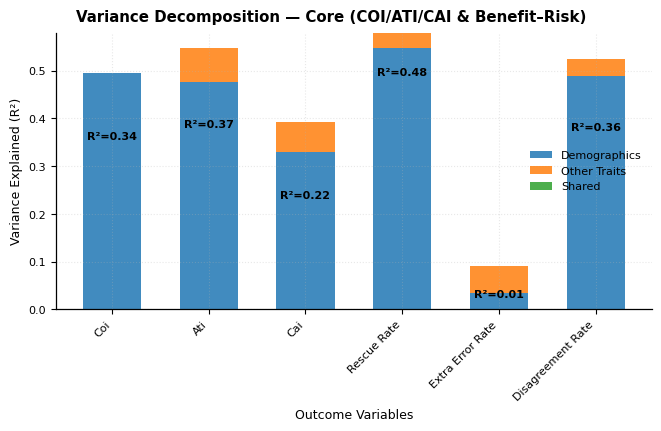

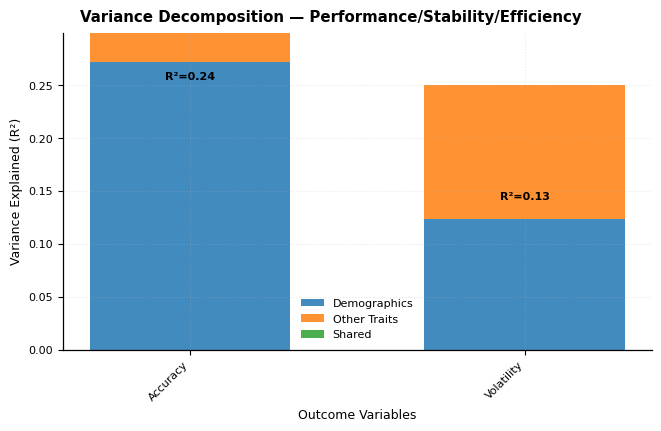

In [79]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.stereotypes_case import stereotypes_case

result_tier3 = run_full_tier3_analysis(merged_df, person_set=PERSON_ETHNICS, case=stereotypes_case,
                                       plots_root="results/figs",
                                        strategy="zero_shot", 
                                        stage="tier3",        
                                        per_figure_subdirs={
                                        "consistency_boldness": "consistency",
                                        "predictive": "predictive_model",
                                        },
                                        save=True)




# Few-shot  
## Analysis results few-shot - stereotype detection

In [80]:
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.stereotypes_case import stereotypes_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"


merged_df = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/few_shot/classic/results_stereotype_few_shot_prompt_short_3examples_binary.csv",
    role_playing_glob_pattern= f"results/{model_foldername}/few_shot/role_playing_ethnics/*/results_stereotype_few_shot_prompt_short_3examples_binary.csv",
    sample_df=sample_mgsd,
    case=stereotypes_case,
)

=== Found 60 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'stereotype_type', 'profile1', 'profile2', 'profile3', 'profile4', 'profile5', 'profile6', 'profile7', 'profile8', 'profile9', 'profile10', 'profile11', 'profile12', 'profile13', 'profile14', 'profile15', 'profile16', 'profile17', 'profile18', 'profile19', 'profile20', 'profile21', 'profile22', 'profile23', 'profile24', 'profile25', 'profile26', 'profile27', 'profile28', 'profile29', 'profile30', 'profile31', 'profile32', 'profile33', 'profile34', 'profile35', 'profile36', 'profile37', 'profile38', 'profile39', 'profile40', 'profile41', 'profile42', 'profile43', 'profile44', 'profile45', 'profile46', 'profile47', 'profile48', 'profile49', 'profile50', 'profile51', 'profile52', 'profile53', 'profile54', 'profile55', 'profile56', 'profile57', 'profile58', 'profile59', 'profile60', 'prompt_tokens__base_pred', 'completion_tokens__base_pred', 'tokens_used__base_pred', 'max_t

In [81]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS

results_preliminary = run_full_preliminary_analysis(merged_df, 
                                                    case=stereotypes_case,
                                                    df = sample_mgsd, 
                                                    person_set=PERSON_ETHNICS,
                                                    plots_root="results/figs",
                                                    strategy="few_shot",
                                                    stage="preliminary",
                                                    per_figure_subdirs={"accuracy_by_group":"acc", "demographic":"demog", "token_econ":"tokens"})

Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

Exploratory Accuracy Differences (descriptive)

Note: This Tier-0 section is descriptive. Formal inference (tests, adjusted p-values, and pre-specified hypotheses) is reported in Tier-1 (GLM/clustered).

Executive Summary
----------------------------------------
Total Comparisons Performed: 32

Largest Absolute Δ (percentage points)
----------------------------------------
 1. Black vs Indian                     Δ = -1.4 pp
 2. Indian vs White                     Δ = +1.1 pp
 3. Indian vs Latine                    Δ = +1.1 pp
 4. Black vs Middle Eastern             Δ = -0.9 pp
 5. Asian vs Indian                     Δ = -0.9 pp

Detailed results
[—] man_vs_woman                        | Man: 0.716 | Woman: 0.714
         Δ = +0.3 pp   95% CI [-0.2, +0.7] pp   h = +0.006


In [82]:
from analysis_1 import run_full_tier1_analysis
from profiles.profile_sets import PERSON_ETHNICS

result_tier1 = run_full_tier1_analysis(merged_df, 
                                       case=stereotypes_case, 
                                       person_set=PERSON_ETHNICS,
                                       figures=True,
                                       plots_root="results/figs",
                                       strategy="few_shot", 
                                       stage="tier1",
                                       per_figure_subdirs={"risk_benefit":"risk", "token_econ":"tokens"})


=== Tier-1 (profiles-only) GLM ===
Formula: correct ~ C(gender, Treatment(reference='man')) + C(ethnicity, Treatment(reference='white')) + C(gender, Treatment(reference='man')):C(ethnicity, Treatment(reference='white'))
Baselines: gender=man, ethnicity=white
n_rows=30,000 | n_items=500 | n_profiles=60
Clustered on: sample_id (n_clusters=500)

-- Block Wald tests --
   - main:C(ethnicity): F(5, 499)=1.68, p=0.1387
   - main:C(gender): F(1, 499)=1.18, p=0.277
   - inter:C(gender):C(ethnicity): F(5, 499)=0.843, p=0.5195

================ GLM (profiles-only, Binomial) ================
Formula: correct ~ C(gender, Treatment(reference='man')) + C(ethnicity, Treatment(reference='white')) + C(gender, Treatment(reference='man')):C(ethnicity, Treatment(reference='white'))
n_rows=30,000, n_profiles=60, n_items=500
Clustered on: sample_id

-- Block Wald tests --
                       block test     stat  df1   df2        p
           main:C(ethnicity)    F 1.676000    5 499.0 0.138698
          

In [83]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

result_tier2 = run_full_tier2_analysis(
    merged_df=merged_df,
    case=stereotypes_case,
    person_set=PERSON_ETHNICS,
    group_keys=("gender", "ethnicity"),
    plots_root="results/figs",
    strategy="few_shot",
    stage="tier2",
    per_figure_subdirs={
        "ensembles": "ensembles",
        "clusters": "clusters",
        "traits": "trait_comparison",
        "recommendations": "recommendations",
        "permutations": "permutation_tests",
    })

EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (500, 308)
Category columns from CaseConfig: ['stereotype_type']
Using provided group keys: ('gender', 'ethnicity')
Dataset shape: (500, 308)
[INFO] Suppressing low-n values in stereotype_type (n<50): religion (n=16)
   • Worst-case 95% half-width at n=16: ±24.5pp
[DEV/TEST] dev n=348, test n=152 (stratified by stereotype_type)

=== Running Step 1: Ensemble by Trait Analysis (DEV selection) ...
ENSEMBLE BY TRAIT ANALYSIS - PERSONSET VERSION
Group keys: ('gender', 'ethnicity')
Building trait groups with keys: ('gender', 'ethnicity')
Found 60 profile columns
Discovered trait values:
  gender: ['man', 'woman']
  ethnicity: ['asian', 'black', 'indian', 'latine', 'middle_eastern', 'white']
Created 12 trait groups:
  man_asian: 5 profiles
  man_black: 5 profiles
  man_indian: 5 profiles
  man_latine: 5 profiles
  man_middle_eastern: 5 profiles
  man_white: 5 profiles
  woman_asian: 5 profiles


EXECUTING TIER 3 ANALYSIS PIPELINE
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
CONSISTENCY vs BOLDNESS TRADEOFF ANALYSIS
Group keys for analysis: ('gender', 'ethnicity', 'age')
Found 60 valid profiles out of 60 total profile columns
=== Calculating consistency across 5 stratified folds...
=== Calculating boldness metrics (COI/ATI/CAI) and global rescue/extra-error...
=== Analyzing consistency-boldness correlations by demographics...
Analysis dataset shape: (60, 19)

--- OVERALL CORRELATION RESULTS:
  Volatility vs Boldness: r=-0.316, p=0.0141, q=0.0214 ***
  Consistency vs Boldness: r=0.315, p=0.0143 ***
  Volatility vs Rescue Rate: r=-0.263, p=0.0424 ***
  Boldness vs Accuracy: r=0.234, p=0.0721 

--- CORRELATIONS BY GENDER:
  man (n=30): Volatility vs Boldness r=-0.217, p=0

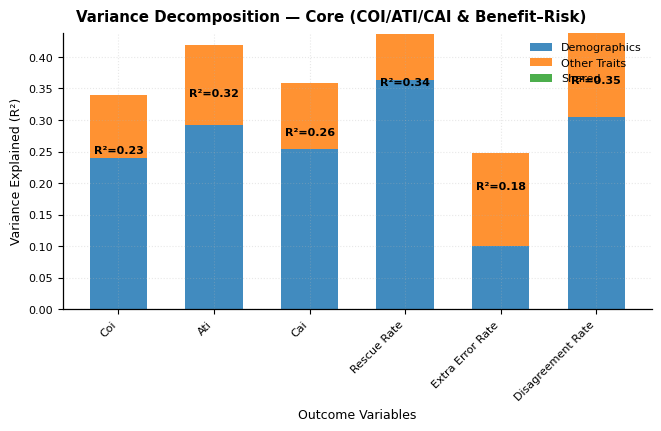

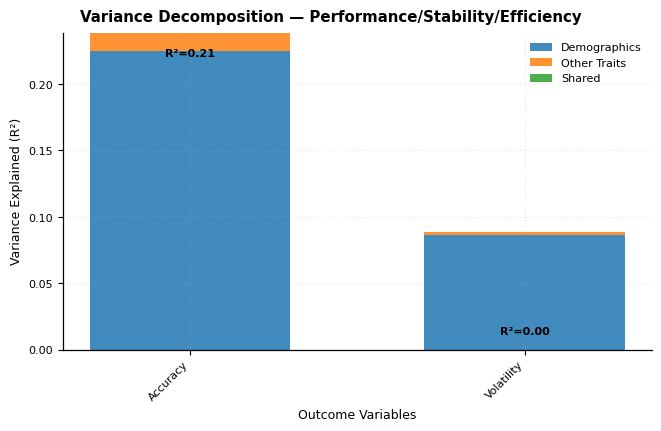

In [84]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS

result_tier3 = run_full_tier3_analysis(merged_df, person_set=PERSON_ETHNICS, 
                                        case=stereotypes_case,
                                        plots_root="results/figs",
                                        strategy="few_shot", 
                                        stage="tier3",
                                        per_figure_subdirs={
                                            "consistency_boldness": "consistency",
                                            "predictive": "predictive_model",
                                        },
                                        save=True)

# Chain-of-Thoughts

### Analysis results chain-of-thoughts - stereotype detection

In [85]:
from typing import Literal
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.stereotypes_case import stereotypes_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"

merged_df_cot = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/cot/classic/results_stereotype_optimized_cot.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/cot/role_playing_ethnics/*/results_stereotype_optimized_cot.csv",
    sample_df=sample_mgsd,
    case=stereotypes_case
)

=== Found 60 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'stereotype_type', 'profile1', 'profile2', 'profile3', 'profile4', 'profile5', 'profile6', 'profile7', 'profile8', 'profile9', 'profile10', 'profile11', 'profile12', 'profile13', 'profile14', 'profile15', 'profile16', 'profile17', 'profile18', 'profile19', 'profile20', 'profile21', 'profile22', 'profile23', 'profile24', 'profile25', 'profile26', 'profile27', 'profile28', 'profile29', 'profile30', 'profile31', 'profile32', 'profile33', 'profile34', 'profile35', 'profile36', 'profile37', 'profile38', 'profile39', 'profile40', 'profile41', 'profile42', 'profile43', 'profile44', 'profile45', 'profile46', 'profile47', 'profile48', 'profile49', 'profile50', 'profile51', 'profile52', 'profile53', 'profile54', 'profile55', 'profile56', 'profile57', 'profile58', 'profile59', 'profile60', 'prompt_tokens__base_pred', 'completion_tokens__base_pred', 'tokens_used__base_pred', 'max_t

In [86]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.stereotypes_case import stereotypes_case

results_cot = run_full_preliminary_analysis(merged_df_cot, case=stereotypes_case, df=sample_mgsd, person_set=PERSON_ETHNICS,
                                            plots_root="results/figs",
                                            strategy="cot",
                                            stage="preliminary",
                                            per_figure_subdirs={"accuracy_by_group":"acc", "demographic":"demog", "token_econ":"tokens"})

Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

Exploratory Accuracy Differences (descriptive)

Note: This Tier-0 section is descriptive. Formal inference (tests, adjusted p-values, and pre-specified hypotheses) is reported in Tier-1 (GLM/clustered).

Executive Summary
----------------------------------------
Total Comparisons Performed: 32

Largest Absolute Δ (percentage points)
----------------------------------------
 1. Indian vs Middle Eastern            Δ = +1.4 pp
 2. Black vs Indian                     Δ = -1.2 pp
 3. Indian vs White                     Δ = +0.9 pp
 4. Asian vs Indian                     Δ = -0.9 pp
 5. Indian vs Latine                    Δ = +0.9 pp

Detailed results
[—] man_vs_woman                        | Man: 0.736 | Woman: 0.740
         Δ = -0.4 pp   95% CI [-1.2, +0.3] pp   h = -0.009


In [87]:
from analysis_1 import run_full_tier1_analysis

result_tier1_cot = run_full_tier1_analysis(merged_df_cot, case=stereotypes_case, person_set=PERSON_ETHNICS,
                                            figures=True,
                                            plots_root="results/figs",
                                            strategy="cot", 
                                            stage="tier1",
                                            per_figure_subdirs={"risk_benefit":"risk", "token_econ":"tokens"})


=== Tier-1 (profiles-only) GLM ===
Formula: correct ~ C(gender, Treatment(reference='man')) + C(ethnicity, Treatment(reference='white')) + C(gender, Treatment(reference='man')):C(ethnicity, Treatment(reference='white'))
Baselines: gender=man, ethnicity=white
n_rows=30,000 | n_items=500 | n_profiles=60
Clustered on: sample_id (n_clusters=500)

-- Block Wald tests --
   - main:C(ethnicity): F(5, 499)=1.52, p=0.1813
   - inter:C(gender):C(ethnicity): F(5, 499)=0.474, p=0.7955
   - main:C(gender): F(1, 499)=0.0538, p=0.8167

================ GLM (profiles-only, Binomial) ================
Formula: correct ~ C(gender, Treatment(reference='man')) + C(ethnicity, Treatment(reference='white')) + C(gender, Treatment(reference='man')):C(ethnicity, Treatment(reference='white'))
n_rows=30,000, n_profiles=60, n_items=500
Clustered on: sample_id

-- Block Wald tests --
                       block test     stat  df1   df2        p
           main:C(ethnicity)    F 1.521986    5 499.0 0.181258
inter:C

In [88]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

#perf_df_cot = (result_tier1_cot.get("token_economics") or {}).get("per_profile")

results_tier2_cot = run_full_tier2_analysis(
    merged_df=merged_df_cot,
    person_set=PERSON_ETHNICS,
    case=stereotypes_case,
    group_keys=("gender", "ethnicity"),
    #perf_df=perf_df_cot,
    plots_root="results/figs",
    strategy="cot",
    stage="tier2",
    per_figure_subdirs={
        "ensembles": "ensembles",
        "clusters": "clusters",
        "traits": "trait_comparison",
        "recommendations": "recommendations",
        "permutations": "permutation_tests",
    }
)


EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (500, 308)
Category columns from CaseConfig: ['stereotype_type']
Using provided group keys: ('gender', 'ethnicity')
Dataset shape: (500, 308)
[INFO] Suppressing low-n values in stereotype_type (n<50): religion (n=16)
   • Worst-case 95% half-width at n=16: ±24.5pp
[DEV/TEST] dev n=348, test n=152 (stratified by stereotype_type)

=== Running Step 1: Ensemble by Trait Analysis (DEV selection) ...
ENSEMBLE BY TRAIT ANALYSIS - PERSONSET VERSION
Group keys: ('gender', 'ethnicity')
Building trait groups with keys: ('gender', 'ethnicity')
Found 60 profile columns
Discovered trait values:
  gender: ['man', 'woman']
  ethnicity: ['asian', 'black', 'indian', 'latine', 'middle_eastern', 'white']
Created 12 trait groups:
  man_asian: 5 profiles
  man_black: 5 profiles
  man_indian: 5 profiles
  man_latine: 5 profiles
  man_middle_eastern: 5 profiles
  man_white: 5 profiles
  woman_asian: 5 profiles


EXECUTING TIER 3 ANALYSIS PIPELINE
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
CONSISTENCY vs BOLDNESS TRADEOFF ANALYSIS
Group keys for analysis: ('gender', 'ethnicity', 'age')
Found 60 valid profiles out of 60 total profile columns
=== Calculating consistency across 5 stratified folds...
=== Calculating boldness metrics (COI/ATI/CAI) and global rescue/extra-error...
=== Analyzing consistency-boldness correlations by demographics...
Analysis dataset shape: (60, 19)

--- OVERALL CORRELATION RESULTS:
  Volatility vs Boldness: r=-0.185, p=0.1562, q=0.1931 
  Consistency vs Boldness: r=0.189, p=0.1480 
  Volatility vs Rescue Rate: r=-0.183, p=0.1609 
  Boldness vs Accuracy: r=-0.049, p=0.7080 

--- CORRELATIONS BY GENDER:
  man (n=30): Volatility vs Boldness r=0.147, p=0.4378 
  

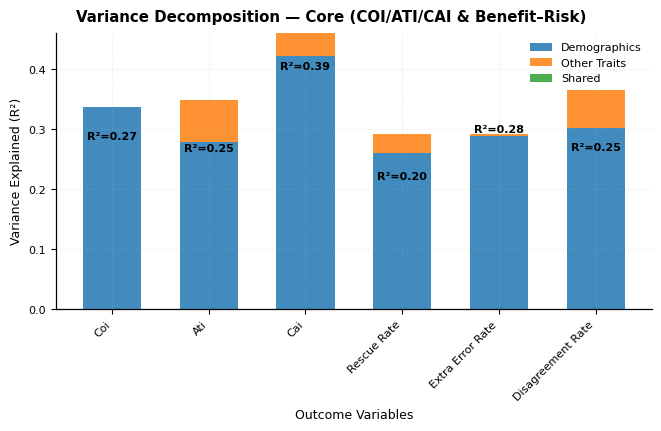

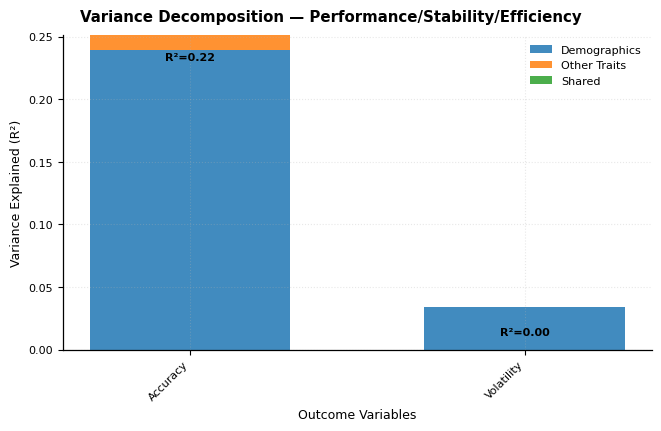

In [89]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.stereotypes_case import stereotypes_case

result_tier3_cot = run_full_tier3_analysis(merged_df_cot, person_set=PERSON_ETHNICS, case=stereotypes_case, 
                                            plots_root="results/figs",
                                            strategy="cot", 
                                            stage="tier3",        
                                            per_figure_subdirs={
                                             "consistency_boldness": "consistency",
                                             "predictive": "predictive_model",
                                            },
                                            save=True)